## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Tesher Baer

**Date:** 10/2/2026

In [1]:
import pandas as pd
import numpy as np 


# Your Phase 1 solution to the problem goes here.
#Part 1
## Question 1
print("""Question 1:
The difference is whether the variable is quantitative or categorical. 
We use regression if the target variable is quantitative. 
It is used if we want to predict a numerical value. If a target variable is categorical, 
however, we use classification and that would help predict the class an observation should" 
go in.""")

##Question 2
print("""Question 2 
A confusion table is helpful for gauging the accuracy of a model. It compares the actual class 
labels with those that were predicted by a classification model. 
It is also useful for showing what classes are usually predicted well by a model, 
and which ones it tends to confuse.""")

##Question 3
print("""Question 3:
The SSE quantifies the total squared difference between the values that a model predicted and 
the actual values. If the value is lower, then the model generally did a better job predicting 
values. """)

##Question 4
print("""Question 4: 
If a model is too close to training data, and thus underperforms on new data, that is called 
overfitting, as it fits the training data too closely. Underfitting, on the other hand, is 
when a model is too simple and was not trained well enough to stop patterns in the data, 
thus also making it not a great predictor.""")

##Question 5
print("""Question 5:
A model can miss observations during training, so splitting the data can help us observe those 
things it missed. It gives a more clear picture and estimate of how accurately the model can 
generalize new data. This assistance in choosing the right k value that will neither overfit 
nor underfit.""")

##Question 6
print("""Question 6
A prediction label is easy to interpret since it is only one classification, but it can hide the 
uncertainty in a model, making it potentially unreliable. Probability distributions are more 
difficult to interpret, but their strength is that they can show how the model performs with 
and supports all possible classes, so we can have more confident predictions. """)

Question 1:
The difference is whether the variable is quantitative or categorical. 
We use regression if the target variable is quantitative. 
It is used if we want to predict a numerical value. If a target variable is categorical, 
however, we use classification and that would help predict the class an observation should" 
go in.
Question 2 
A confusion table is helpful for gauging the accuracy of a model. It compares the actual class 
labels with those that were predicted by a classification model. 
It is also useful for showing what classes are usually predicted well by a model, 
and which ones it tends to confuse.
Question 3:
The SSE quantifies the total squared difference between the values that a model predicted and 
the actual values. If the value is lower, then the model generally did a better job predicting 
values. 
Question 4: 
If a model is too close to training data, and thus underperforms on new data, that is called 
overfitting, as it fits the training data too closely. 

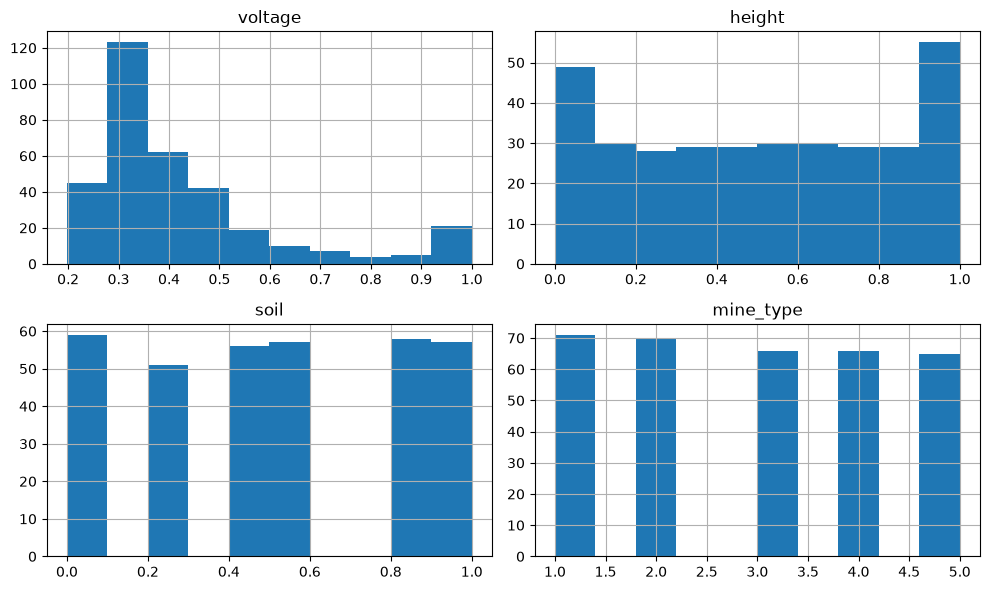

Best k is: 2
Most accurate is: 0.40828402366863903


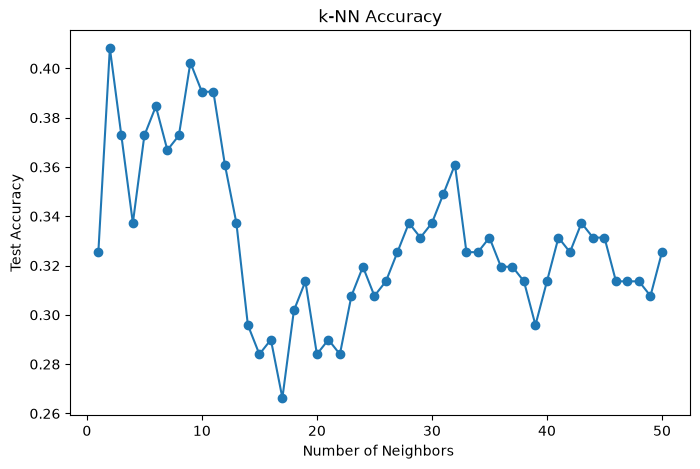

          Predicted 1  Predicted 2  Predicted 3  Predicted 4  Predicted 5
Actual 1           23            0           11            4            1
Actual 2            0           27            1            3            0
Actual 3           11            1           13            7            2
Actual 4           13            5            7            5            2
Actual 5           10            1           12            9            1
Accuracy: 0.40828402366863903
The model performed quite poorly, with an accuracy of approximately 40.8 percent, 
even when using an optimal k value of 2. Therefore, using solely this model to make predictions 
is not something I would advise. In looking at the confusion table, however, there are some 
aspects in which the model is more useful than others. For instance, it correctly classified 27 
of 31 of Type 2 mines, whereas it only correctly guessed 5 out of 32 Type 4 mines. So, the model 
does potentially serve a purpose in prediction, but it sho

In [2]:
#Part 2
#import necessary packages 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt


#question 1 - load data and do some EDA
mines = pd.read_csv("data/land_mines.csv")
##examine data
mines.head()
mines.shape
mines.info
mines.describe
#look at target variable, mine_type, and add proportions
mines["mine_type"].value_counts().sort_index()
mines["mine_type"].value_counts(normalize=True).sort_index()
#missing values?
mines.isna().sum()
#visualize it
mines.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

#quesion 2 - 50/50 split 
#divide x and y and plit them
X = mines[["voltage", "height", "soil"]]
y = mines["mine_type"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=1
)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#question 3 - fit a kNN model with k=1
#test k 
k_values = range(1, 51)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, predictions)
    accuracies.append(accuracy)

#optinal k?
best_accuracy = max(accuracies)
best_k = k_values[accuracies.index(best_accuracy)]

print("Best k is:", best_k)
print("Most accurate is:", best_accuracy)
#map it 
plt.figure(figsize=(8, 5))
#this k is what we will use for the confusion matrix

plt.plot(k_values, accuracies, marker="o")

plt.xlabel("Number of Neighbors ")
plt.ylabel("Test Accuracy")
plt.title("k-NN Accuracy")

plt.show()

#quesiton 4 - confusion matrix for best k
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
#clean it up
cm_table = pd.DataFrame(
    cm,
    index=["Actual 1", "Actual 2", "Actual 3", "Actual 4", "Actual 5"],
    columns=["Predicted 1", "Predicted 2", "Predicted 3", "Predicted 4", "Predicted 5"]
)
print(cm_table)
#accuracy?
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#question 5 - how someone should use this model? things to keep in mind
print("""The model performed quite poorly, with an accuracy of approximately 40.8 percent, 
even when using an optimal k value of 2. Therefore, using solely this model to make predictions 
is not something I would advise. In looking at the confusion table, however, there are some 
aspects in which the model is more useful than others. For instance, it correctly classified 27 
of 31 of Type 2 mines, whereas it only correctly guessed 5 out of 32 Type 4 mines. So, the model 
does potentially serve a purpose in prediction, but it should only be used in tandem with other 
models. What this tells us is that using a singular model is not the best approach for predictions, 
and that analysts should consider the Types that tend to perform particularly poorly when interpreting a 
prediction model’s projections. """)



## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** Claude Sonnet 5.5

### *Prompts used

1. what recommendations do you have for parts 1 and 2 to address prompts? if there are any changes need? if nothing is inaccurate or lacking, you do not need to recommend anything.
2. Display the exact changes you would make

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Question 1 part 2 suggested revision: "It gives an honest estimate of out-of-sample performance, which lets you pick the k that generalizes rather than the one that memorizes the training data."
2. Question 1 part 6 suggested revision: "probabilities quantify uncertainty and let you set decision thresholds or account for unequal error costs. Weaknesses: kNN probabilities are coarse (multiples of 1/k), may be poorly calibrated, and are harder to communicate."
3. Question 2 suggestions:
EDA doesn't display anything. A notebook cell only shows its last expression, and mines.info and mines.describe are missing (). Only the histograms appear. Wrap head(), shape, info(), describe(), and the value_counts calls in print() or display() (or split them across cells), and add a sentence or two on what you see: class balance, feature ranges, missing values. The prompt asks you to summarize the target and features.
Split: Consider stratify=y, since the prompt specifically warns about classes disappearing from one side.
Selecting k: The prompt says "explain how you select k," but that explanation exists only as code comments. Add a short written explanation. The scaling is good, and fitting the scaler on training data only is correct. Say why you scaled (kNN is distance-based).
k=2 is a questionable choice. Two neighbors means ties get broken arbitrarily, and it's high variance. Also, you choose k on the test set and then report accuracy on that same set, which is slightly optimistic. The prompt allows this approach, but mention the caveat, or use cross-validation on the training set. Compare the winning accuracy to its neighbors on your plot to see whether it's a real peak or noise.
Comment mismatch: "fit a kNN model with k=1" doesn't match what the code does.
Q4 interpretation: The question asks where performance is more or less accurate, but that analysis only appears in your Q5 text. Also, your Q5 says Type 4 is the worst, but Type 5 is worse: only 1 of 33 correct (about 3%) versus 5 of 32 for Type 4. Your other numbers check out (27/31 for Type 2, and 69/169 ≈ 40.8% overall). A useful reference point is the baseline of about 20–23% from guessing the most common class.
Q5 misses the main point. The prompt hints at precision versus recall. Reading the confusion table by columns, when the model predicts Type 1, it's right only 23 of 57 times (about 40%), even though it finds 59% of true Type 1 mines. Your current answer ("use alongside other models," "a single model isn't the best approach") is vague and doesn't follow from the table. Stronger practical advice:
Treat predictions as leads, not verdicts, and assume any mine could be any type, since mistakes here are costly.
Trust "Type 2" predictions most (the best precision and recall).
Be skeptical of predictions of Types 1, 3, 4, and 5.
Use predicted probabilities (predict_proba) to flag low-confidence cases for manual or additional testing.
Collect more features or data.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept  | It does more fully and accurately address the question |
| 2 | Accept  | It does more fully and accurately address the question |
| 3 | Accept | This lab I found quite confusing, and looking at the results, it does seem to address everything more clearly |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [3]:
# Your Phase 2 solution to the problem goes here.
#Part 1: AI Version
print("""Question 1:
Regression and classification differ in the type of target variable. Regression predicts a
quantitative (numerical) target, such as a price or a temperature. Classification predicts a
categorical target, meaning the class or label an observation belongs to.

Question 2:
A confusion table cross-tabulates the actual class labels against the labels a classification
model predicted. Beyond overall accuracy, it shows which classes the model predicts well, and
which classes it tends to confuse with one another (the per-class errors).

Question 3:
The SSE (sum of squared errors) is the total of the squared differences between the model's
predicted values and the actual values. A lower SSE means the predictions are closer to the
truth. It is the regression counterpart of accuracy for classification.

Question 4:
Overfitting happens when a model fits the training data too closely, including its noise, so it
performs well on training data but poorly on new data. Underfitting happens when a model is too
simple to capture the real patterns in the data, so it performs poorly on both. In k-NN, a very
small k tends to overfit (predictions depend on a few nearby points), while a very large k tends
to underfit (predictions get averaged over too much of the data).

Question 5:
Splitting the data does not make the model itself better. It gives an honest estimate of how the
model performs on data it has not seen. A model evaluated on its own training data looks
deceptively good (for example, k=1 is perfectly accurate on training data). By comparing accuracy
or SSE on the held-out test set across different values of k, we can choose the k that
generalizes best, rather than the k that merely memorizes the training data. That is how we
avoid both overfitting and underfitting.

Question 6:
A class label is simple to communicate and act on, but it hides how certain the model is: a
prediction made with 90% confidence looks identical to one made with 40%. A probability
distribution preserves that uncertainty, lets us set decision thresholds, and lets us weigh
different kinds of mistakes differently when some errors are costlier than others. Its
weaknesses are that it is harder to interpret and communicate, and that k-NN probabilities are
coarse (they come in multiples of 1/k) and may not be well calibrated, so a stated 70% may not
really mean 70%.""")

Question 1:
Regression and classification differ in the type of target variable. Regression predicts a
quantitative (numerical) target, such as a price or a temperature. Classification predicts a
categorical target, meaning the class or label an observation belongs to.

Question 2:
A confusion table cross-tabulates the actual class labels against the labels a classification
model predicted. Beyond overall accuracy, it shows which classes the model predicts well, and
which classes it tends to confuse with one another (the per-class errors).

Question 3:
The SSE (sum of squared errors) is the total of the squared differences between the model's
predicted values and the actual values. A lower SSE means the predictions are closer to the
truth. It is the regression counterpart of accuracy for classification.

Question 4:
Overfitting happens when a model fits the training data too closely, including its noise, so it
performs well on training data but poorly on new data. Underfitting happens 

First rows:
    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1 

Shape (rows, columns): (338, 4) 

Column types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB

Summary statistics:
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      

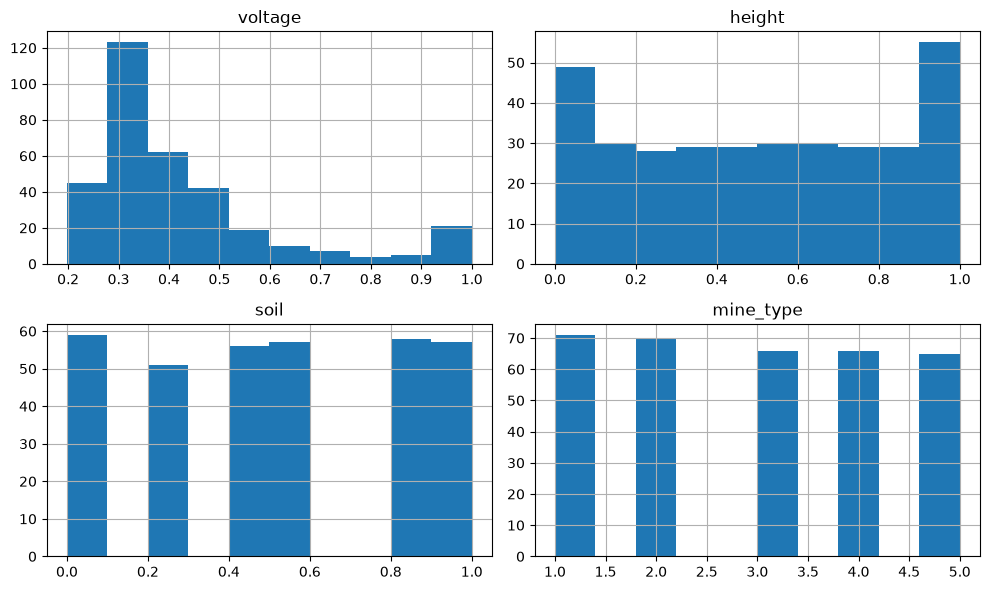

Best k: 2
Test accuracy at best k: 0.4438
k chosen by 5-fold CV on the training data: 2 



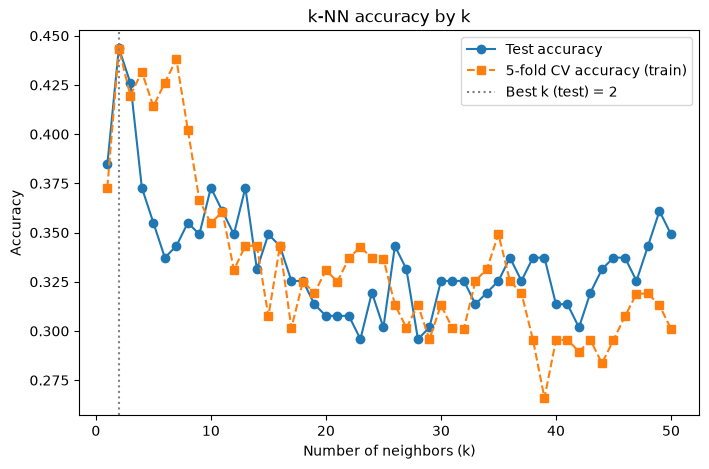

Note: k is chosen using the test set, as the assignment specifies, so the accuracy reported for that k is slightly optimistic. Very small k values (like k=2) are also high-variance and can produce ties. If the accuracy curve is flat or noisy around the best k, the exact choice matters little.

          Predicted 1  Predicted 2  Predicted 3  Predicted 4  Predicted 5
Actual 1           21            0           10            2            2
Actual 2            0           30            0            5            0
Actual 3            7            0           18            8            0
Actual 4           16            5            8            4            0
Actual 5           12            0           16            3            2 

Overall accuracy: 0.4438
        recall  precision
Type 1   0.600      0.375
Type 2   0.857      0.857
Type 3   0.545      0.346
Type 4   0.121      0.182
Type 5   0.061      0.500 

Interpretation: overall accuracy is 44.4% (baseline from always guessing the

In [4]:
#Part 2: AI Version 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# ---------------------------------------------------------------
# Question 1: Load the data and perform EDA
# ---------------------------------------------------------------
mines = pd.read_csv("data/land_mines.csv")

print("First rows:")
print(mines.head(), "\n")
print("Shape (rows, columns):", mines.shape, "\n")
print("Column types and non-null counts:")
mines.info()
print("\nSummary statistics:")
print(mines.describe(), "\n")
print("Missing values per column:")
print(mines.isna().sum(), "\n")

# Target label: counts and proportions
counts = mines["mine_type"].value_counts().sort_index()
props = mines["mine_type"].value_counts(normalize=True).sort_index()
print("Target label (mine_type):")
print(pd.DataFrame({"count": counts, "proportion": props.round(3)}), "\n")

baseline = props.max()
print(f"EDA summary: the data have {mines.shape[0]} observations, three numeric features "
      f"(voltage, height, soil), and a target with {mines['mine_type'].nunique()} classes. "
      f"The classes are fairly balanced; the most common class makes up {baseline:.1%} of the data, "
      f"so always guessing that class would be about {baseline:.1%} accurate. That is the baseline "
      f"any useful model should beat.\n")

# Distributions of the variables
mines.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Question 2: 50/50 train/test split
# ---------------------------------------------------------------
X = mines[["voltage", "height", "soil"]]
y = mines["mine_type"]

# stratify=y keeps the class proportions the same in both halves,
# so no class ends up concentrated in only the training or test set.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=1, stratify=y
)

# k-NN is distance-based, so features on larger scales would dominate the distance.
# We rescale all features to [0, 1], fitting the scaler on the training data only.
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------------
# Question 3: Build a k-NN classifier and select k
# ---------------------------------------------------------------
# To select k, I fit a k-NN classifier on the training set for each k from 1 to 50,
# compute accuracy on the held-out test set, and pick the k with the highest test accuracy.
k_values = range(1, 51)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    accuracies.append(accuracy_score(y_test, model.predict(X_test_scaled)))

best_accuracy = max(accuracies)
best_k = list(k_values)[accuracies.index(best_accuracy)]  # smallest k among ties

print("Best k:", best_k)
print("Test accuracy at best k:", round(best_accuracy, 4))

# Sanity check: 5-fold cross-validation on the training set only.
# This is less affected by the luck of a single split.
cv_scores = [
    cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train_scaled, y_train, cv=5).mean()
    for k in k_values
]
cv_best_k = list(k_values)[int(np.argmax(cv_scores))]
print("k chosen by 5-fold CV on the training data:", cv_best_k, "\n")

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker="o", label="Test accuracy")
plt.plot(k_values, cv_scores, marker="s", linestyle="--", label="5-fold CV accuracy (train)")
plt.axvline(best_k, color="gray", linestyle=":", label=f"Best k (test) = {best_k}")
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Accuracy")
plt.title("k-NN accuracy by k")
plt.legend()
plt.show()

print("Note: k is chosen using the test set, as the assignment specifies, so the accuracy "
      "reported for that k is slightly optimistic. Very small k values (like k=2) are also "
      "high-variance and can produce ties. If the accuracy curve is flat or noisy around the "
      "best k, the exact choice matters little.\n")

# ---------------------------------------------------------------
# Question 4: Confusion table for the optimal model
# ---------------------------------------------------------------
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_table = pd.DataFrame(
    cm,
    index=[f"Actual {c}" for c in labels],
    columns=[f"Predicted {c}" for c in labels],
)
print(cm_table, "\n")

accuracy = accuracy_score(y_test, y_pred)
print("Overall accuracy:", round(accuracy, 4))

# Recall: of the mines that really are type c, what share did we label type c? (rows)
# Precision: of the mines we labeled type c, what share really are type c? (columns)
diag = np.diag(cm)
recall = diag / cm.sum(axis=1)
precision = np.divide(diag, cm.sum(axis=0), out=np.zeros(len(diag)), where=cm.sum(axis=0) > 0)
per_class = pd.DataFrame(
    {"recall": recall.round(3), "precision": precision.round(3)},
    index=[f"Type {c}" for c in labels],
)
print(per_class, "\n")

best_class = labels[int(np.argmax(recall))]
worst_class = labels[int(np.argmin(recall))]
print(f"Interpretation: overall accuracy is {accuracy:.1%} (baseline from always guessing the "
      f"most common class: {baseline:.1%}). The model is most accurate for Type {best_class} "
      f"mines (recall {recall.max():.1%}) and least accurate for Type {worst_class} mines "
      f"(recall {recall.min():.1%}). Performance is therefore very uneven across mine types.\n")

# ---------------------------------------------------------------
# Question 5: How to use this model in practice
# ---------------------------------------------------------------
print(f"""Question 5:
With an accuracy of about {accuracy:.1%}, this model should not be used as a final verdict on what
kind of mine something is, because a wrong call in this setting can be dangerous or costly. How
trustworthy a prediction is depends heavily on the predicted type. Reading the confusion table by
column (precision) tells us how much to trust a prediction once the model makes it, while reading
it by row (recall) tells us how many mines of each real type we catch. Type {best_class} predictions
are the most reliable, while predictions of types with low precision should be treated with
skepticism. A model can catch a lot of one type and still be wrong often when it predicts it,
because other types get mislabeled as that type.

In practice I would advise: (1) treat predictions as leads that prioritize further checks, not as
answers; (2) assume any mine could be of any type, especially when the prediction is one of the
low-precision types; (3) use predicted probabilities (predict_proba) to flag low-confidence cases
for extra testing or manual handling; and (4) collect more or better features, since voltage,
height, and soil alone do not separate the types well.""")

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

This lab was by far the one I found the most challenging, and looing over Claude's recommendations, I can really see where I missed the mark in some areas. Some of the mistakes were classic ones that I have made before, such as just forgetting to run a print function explaining the findings of the analysis. Others, however, were suggestions I would not have thought of on my own, such as including stratify=y. This is where I think using AI is particularly useful. I recognize that my coding knowledge is never going to reach the level of that seem in a LLM, such as Claude Sonnet 5.5. Particularly for prediction models, an LLM is especially well-suited, as much of its code is based on assumptions and predictions. It feels a bit odd asking a collection of code to evalute something like "infant code" and give recommendations on how best make that code mature, but I suppose that is its place. I verified the decision to include most of its suggestions by looking up all of the additions and verifying that they would actually do what Claude said they would. 